# Which shipment modes cause the longest delays?


### Objective
This analysis evaluates delivery performance across different shipment modes by examining the percentage distribution of delivery outcomes (early, late, and on-time).

### Methodology
The analysis was conducted in three stages:
1. Aggregation of shipment counts by shipment mode and delivery status
2. Conversion of shipment counts into percentage values per shipment mode
3. Visualization of percentage distributions using a bar chart

This approach ensures comparability between shipment modes regardless of shipment volume.

In [5]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

df = pd.read_csv(r'c:\Users\HP\Downloads\Supply_Chain_Shipment_Pricing_Data.csv')

cols_to_keep = [
    'country', 'vendor', 'shipment mode',
    'product group', 'sub classification',
    'po sent to vendor date', 'scheduled delivery date',
    'delivered to client date',
    'freight cost (usd)', 'line item insurance (usd)'
]
df = df[cols_to_keep]

list_to_date = ['scheduled delivery date', 'delivered to client date']

df = df.copy()                                          # To avoid SettingWithCopyWarning

for col in list_to_date:
    df[col] = pd.to_datetime(df[col], format='mixed')    # mixed format handles different date formats

### Data Aggregation
A pivot table was created to summarize shipment counts by shipment mode and delivery status.

In [12]:
df_delai = df.copy()

df_delai['delay'] = (
    df_delai['scheduled delivery date'] - df_delai['delivered to client date']
    ).dt.days

df_delai['shipment delivery'] = np.where(
    df_delai['delay'] < 0 , 'early',                         # if delay < 0 then 'early'
    np.where(                                                # if delay = 0 then 'on time'
        df_delai['delay'] == 0, 'on time',                   # else 'late'
    'late')
)

df_delai

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0,on time
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16,late
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6,early
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6,late
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36,late


In [14]:
df_mode = df_delai.pivot_table(index='shipment mode',
                     columns= 'shipment delivery',
                     aggfunc= 'size'
                     )

df_mode

shipment delivery,early,late,on time
shipment mode,,,
Air,587,1183,4343
Air Charter,75,452,123
Ocean,65,15,291
Truck,455,1137,1238


### Percentage Calculation

Shipment totals were calculated for each shipment mode, and delivery outcomes were converted into percentages.

In [16]:
df_mode['total'] = df_mode.sum(axis=1)           

df_mode_prc = df_mode.iloc[:].div(df_mode['total'] / 100, axis = 0)

df_mode_prc.drop(columns = 'total', inplace = True)

df_mode_prc


shipment delivery,early,late,on time
shipment mode,,,
Air,4.801243,9.676100,35.522657
Air Charter,5.769231,34.769231,9.461538
Ocean,8.760108,2.021563,39.218329
Truck,8.038869,20.088339,21.872792


### Visualization

The percentage distribution of delivery outcomes by shipment mode was visualized using a bar chart.

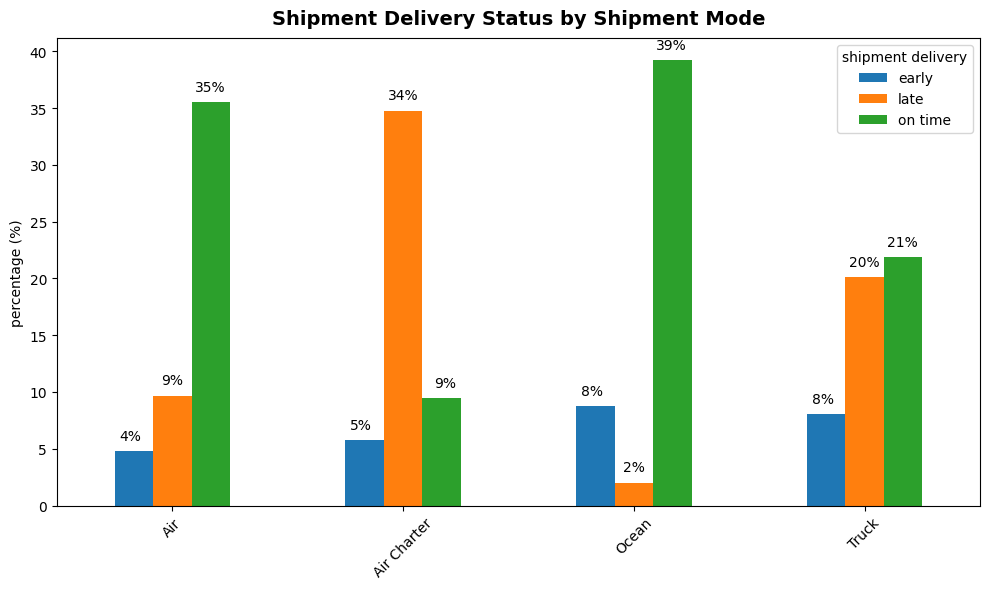

In [17]:
df_mode_prc.plot(kind = 'bar',
            figsize = (10,6),
            xlabel = '',
            ylabel = 'percentage (%)',
             )

for i, j in enumerate(df_mode_prc['early']):
    plt.text(i-0.23, j + 1,  f'{int(j)}%', fontsize = 10, ha = 'left' )
    
for i, j in enumerate(df_mode_prc['late']):
    plt.text(i, j + 1,  f'{int(j)}%', fontsize = 10, ha = 'center')

for i, j in enumerate(df_mode_prc['on time']):
    plt.text(i+0.23, j + 1,  f'{int(j)}%', fontsize = 10, ha = 'right')
    
plt.title('Shipment Delivery Status by Shipment Mode', pad = 10, fontsize = 14, fontweight = 'bold')
plt.xticks(rotation = 45 )
plt.tight_layout()

plt.show()

**Insight:**  
- Delivery reliability varies sharply by shipment mode, with **Ocean showing the strongest on-time performance (78%)** and minimal delays.  
- **Air Charter is the weakest-performing mode**, with the majority of shipments delivered late, creating both service and cost risk.  
- **Aligning shipment urgency with the most reliable modes** would improve on-time performance and reduce overall logistics costs.



---

## Is there a trade-off between delivery time and cost?

### Methodology

The dataset was split by delivery status, and median freight costs were calculated for each shipment mode.

In [21]:
df_C = df_delai.copy()
df_C = df_C[df_C['shipment delivery'].isin(['on time', 'late'])]
df_C = df_C.copy()
df_C["freight cost (usd)"] = pd.to_numeric(df_C["freight cost (usd)"] , errors="coerce")
df_C = df_C.dropna(subset=["freight cost (usd)"])

df_C_late = df_C[df_C['shipment delivery'] == 'late']
df_C_on_time = df_C[df_C['shipment delivery'] == 'on time']

### Visualization

Two side-by-side bar charts were used to compare median freight costs by shipment mode for late and on-time deliveries.

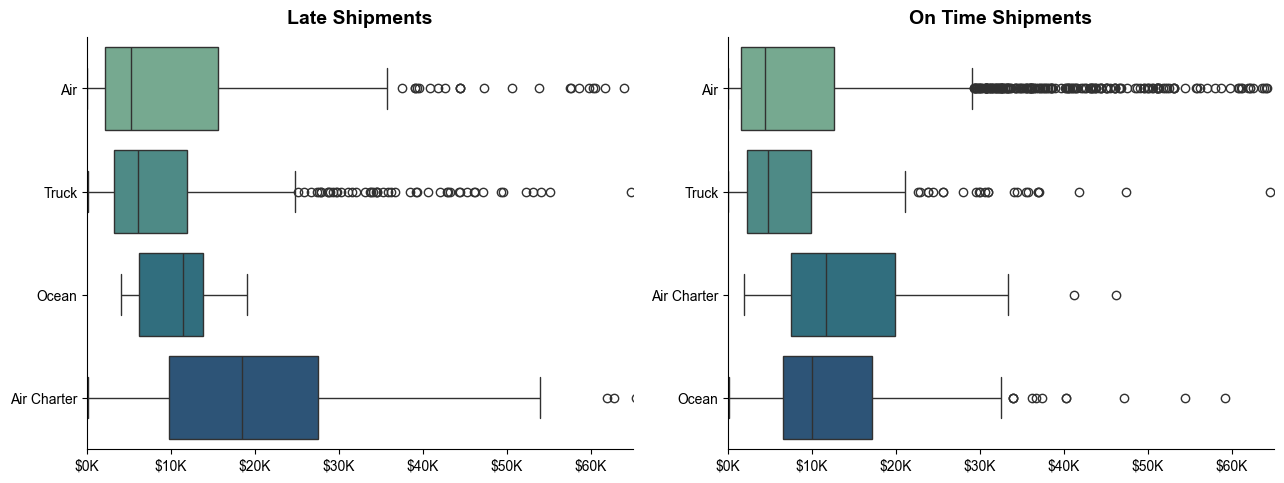

In [22]:
fig , ax = plt.subplots(1,2, figsize=(13,5))

sns.set_theme(style = 'ticks')
sns.boxplot(data = df_C_late,
            x = 'freight cost (usd)',
            y = 'shipment mode',
            ax = ax[0],
            palette='crest',
            hue= 'shipment mode',
            legend=False,
            )
ax[0].set_title('Late Shipments', fontsize=14, fontweight='bold', pad=10)
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
ax[0].set_xlim(0, 65000)

sns.boxplot(data = df_C_on_time,
            x = 'freight cost (usd)',
            y = 'shipment mode',
            ax = ax[1],
            hue='shipment mode',
            palette='crest',
            legend=False,
            )
ax[1].set_title('On Time Shipments', fontsize=14, fontweight='bold', pad=10)
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
ax[1].set_xlim(0, 65000)

sns.despine()

plt.tight_layout()

plt.show()

**Insight:**  
- Late shipments exhibit **higher median freight costs and significantly greater cost variability** across all shipment modes.  
- **Air Charter shows the highest cost exposure and widest spread**, indicating substantial financial risk when delays occur.  
- Improving delivery reliability in **high-cost modes** would generate the largest cost savings and reduce overall freight spend volatility.


